# HW07: Кластеризация

Домашнее задание к семинару 07: анализ методов кластеризации, внутренние метрики качества, PCA/t-SNE.

Выбрано 3 датасета:
- `S07-hw-dataset-01.csv` - числовые признаки в разных шкалах + шум
- `S07-hw-dataset-02.csv` - нелинейная структура + выбросы + шумовой признак
- `S07-hw-dataset-03.csv` - кластеры разной плотности + фоновый шум


In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import json
import warnings
import os

warnings.filterwarnings('ignore')

# Настройка отображения
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline


## Датасет 1: S07-hw-dataset-01.csv

### 2.3.1. Загрузка данных и первичный анализ


In [2]:
# Загрузка датасета 01
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print(f"Размер датасета: {df1.shape}")
df1.head()


Размер датасета: (12000, 9)


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [3]:
# Базовая информация
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [4]:
# Проверка пропусков
print("Пропуски:")
print(df1.isnull().sum())
print(f"\nВсего пропусков: {df1.isnull().sum().sum()}")


Пропуски:
sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64

Всего пропусков: 0


In [5]:
# Базовые статистики
df1.describe()


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [6]:
# Подготовка признаков
X1 = df1.drop('sample_id', axis=1)
sample_ids_1 = df1['sample_id']
print(f"Признаки X1: {X1.shape}")
print(f"Типы признаков: числовые (все признаки числовые)")


Признаки X1: (12000, 8)
Типы признаков: числовые (все признаки числовые)


### 2.3.2. Препроцессинг


In [7]:
# Препроцессинг для датасета 01: только масштабирование (нет пропусков и категориальных признаков)
preprocessor_1 = Pipeline([
    ('scaler', StandardScaler())
])

X1_scaled = preprocessor_1.fit_transform(X1)
print(f"Данные после масштабирования: {X1_scaled.shape}")
print(f"Среднее: {X1_scaled.mean(axis=0)[:3]}, Стандартное отклонение: {X1_scaled.std(axis=0)[:3]}")


Данные после масштабирования: (12000, 8)
Среднее: [-7.10542736e-18 -4.05601478e-17 -7.10542736e-18], Стандартное отклонение: [1. 1. 1.]


### 2.3.3. Модели кластеризации

#### KMeans


In [8]:
# Подбор k для KMeans (датасет 01)
k_range = range(2, 21)
silhouette_scores_1_kmeans = []
db_scores_1_kmeans = []
ch_scores_1_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    
    # Избегаем случая, когда все точки в одном кластере
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X1_scaled, labels)
        db = davies_bouldin_score(X1_scaled, labels)
        ch = calinski_harabasz_score(X1_scaled, labels)
    else:
        sil, db, ch = -1, np.inf, 0
    
    silhouette_scores_1_kmeans.append(sil)
    db_scores_1_kmeans.append(db)
    ch_scores_1_kmeans.append(ch)

# Находим оптимальное k по silhouette
best_k_1 = k_range[np.argmax(silhouette_scores_1_kmeans)]
print(f"Лучшее k по silhouette: {best_k_1}")
print(f"Silhouette score при k={best_k_1}: {silhouette_scores_1_kmeans[best_k_1-2]:.4f}")


Лучшее k по silhouette: 2
Silhouette score при k=2: 0.5216


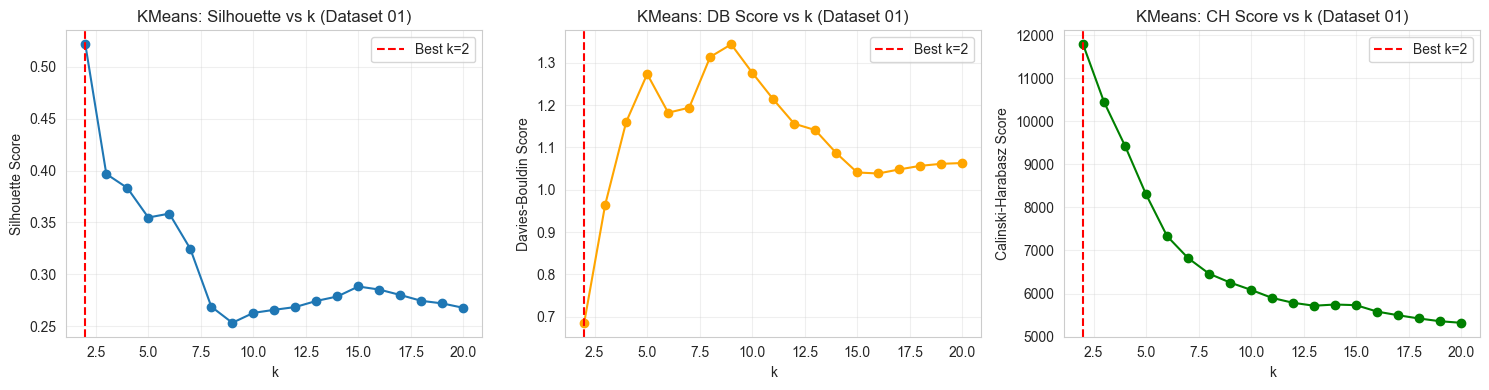

In [9]:
# График метрик vs k для KMeans (датасет 01)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(k_range), silhouette_scores_1_kmeans, marker='o')
axes[0].axvline(x=best_k_1, color='r', linestyle='--', label=f'Best k={best_k_1}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('KMeans: Silhouette vs k (Dataset 01)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(list(k_range), db_scores_1_kmeans, marker='o', color='orange')
axes[1].axvline(x=best_k_1, color='r', linestyle='--', label=f'Best k={best_k_1}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('KMeans: DB Score vs k (Dataset 01)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(list(k_range), ch_scores_1_kmeans, marker='o', color='green')
axes[2].axvline(x=best_k_1, color='r', linestyle='--', label=f'Best k={best_k_1}')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('KMeans: CH Score vs k (Dataset 01)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('artifacts/figures/dataset01_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Обучение KMeans с лучшим k (датасет 01)
kmeans_best_1 = KMeans(n_clusters=best_k_1, random_state=42, n_init=10)
labels_kmeans_1 = kmeans_best_1.fit_predict(X1_scaled)

# Метрики для KMeans
metrics_kmeans_1 = {
    'silhouette': silhouette_score(X1_scaled, labels_kmeans_1),
    'davies_bouldin': davies_bouldin_score(X1_scaled, labels_kmeans_1),
    'calinski_harabasz': calinski_harabasz_score(X1_scaled, labels_kmeans_1)
}

print("Метрики KMeans (датасет 01):")
for metric, value in metrics_kmeans_1.items():
    print(f"  {metric}: {value:.4f}")


Метрики KMeans (датасет 01):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546


#### DBSCAN


In [11]:
# Подбор параметров для DBSCAN (датасет 01)
eps_range = np.arange(0.1, 2.0, 0.1)
min_samples_list = [3, 5, 10]
best_eps_1 = None
best_min_samples_1 = None
best_silhouette_dbscan_1 = -1
results_dbscan_1 = []

for eps in eps_range:
    for min_samples in min_samples_list:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # Пропускаем случаи с слишком большим шумом или малым числом кластеров
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
            
        # Считаем метрики только на non-noise точках
        mask = labels != -1
        if mask.sum() < 2:
            continue
            
        sil = silhouette_score(X1_scaled[mask], labels[mask])
        results_dbscan_1.append({
            'eps': eps, 'min_samples': min_samples, 'silhouette': sil,
            'n_clusters': n_clusters, 'noise_ratio': noise_ratio
        })
        
        if sil > best_silhouette_dbscan_1:
            best_silhouette_dbscan_1 = sil
            best_eps_1 = eps
            best_min_samples_1 = min_samples

if best_eps_1 is not None:
    print(f"Лучшие параметры DBSCAN: eps={best_eps_1:.2f}, min_samples={best_min_samples_1}")
    print(f"Silhouette score: {best_silhouette_dbscan_1:.4f}")
else:
    print("Не удалось найти подходящие параметры DBSCAN")
    # Используем значения по умолчанию
    best_eps_1, best_min_samples_1 = 0.5, 5


Лучшие параметры DBSCAN: eps=1.70, min_samples=3
Silhouette score: 0.5216


In [12]:
# Обучение DBSCAN с лучшими параметрами (датасет 01)
dbscan_best_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
labels_dbscan_1 = dbscan_best_1.fit_predict(X1_scaled)

n_clusters_dbscan_1 = len(set(labels_dbscan_1)) - (1 if -1 in labels_dbscan_1 else 0)
n_noise_dbscan_1 = list(labels_dbscan_1).count(-1)
noise_ratio_dbscan_1 = n_noise_dbscan_1 / len(labels_dbscan_1)

print(f"DBSCAN (датасет 01):")
print(f"  Количество кластеров: {n_clusters_dbscan_1}")
print(f"  Количество шума (label=-1): {n_noise_dbscan_1} ({noise_ratio_dbscan_1:.2%})")

# Метрики на non-noise точках
mask_1 = labels_dbscan_1 != -1
if mask_1.sum() >= 2:
    metrics_dbscan_1 = {
        'silhouette': silhouette_score(X1_scaled[mask_1], labels_dbscan_1[mask_1]),
        'davies_bouldin': davies_bouldin_score(X1_scaled[mask_1], labels_dbscan_1[mask_1]),
        'calinski_harabasz': calinski_harabasz_score(X1_scaled[mask_1], labels_dbscan_1[mask_1]),
        'noise_ratio': noise_ratio_dbscan_1
    }
    print("\nМетрики DBSCAN (на non-noise точках):")
    for metric, value in metrics_dbscan_1.items():
        print(f"  {metric}: {value:.4f}")
else:
    metrics_dbscan_1 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': noise_ratio_dbscan_1}


DBSCAN (датасет 01):
  Количество кластеров: 2
  Количество шума (label=-1): 0 (0.00%)

Метрики DBSCAN (на non-noise точках):
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  noise_ratio: 0.0000


### 2.3.5. Визуализация (PCA 2D)


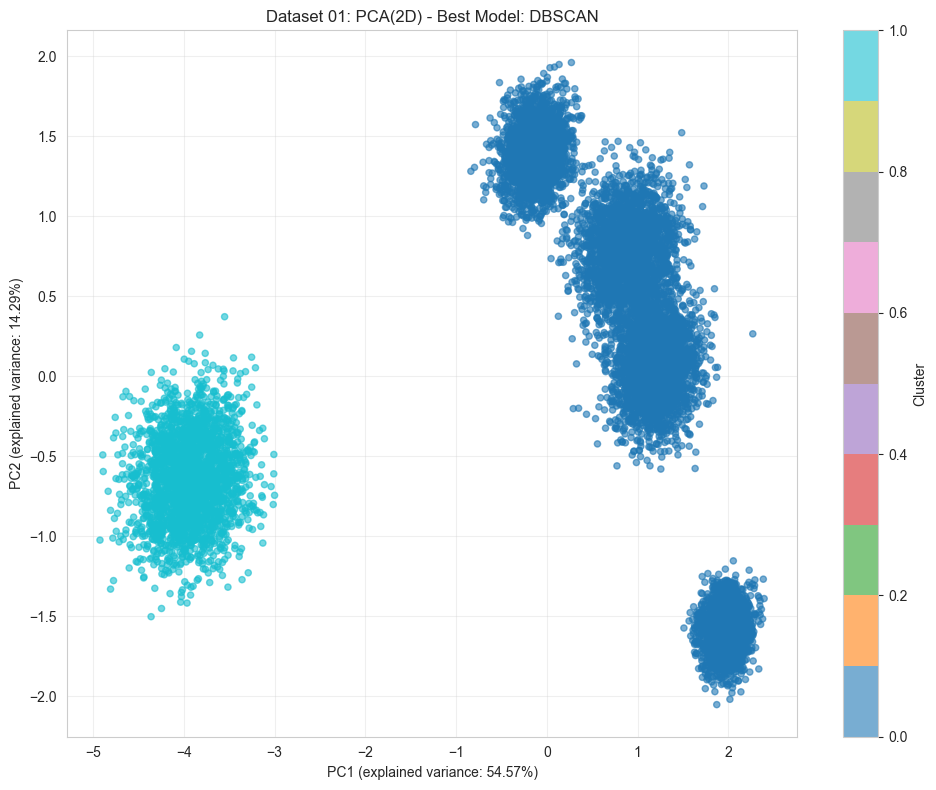

Выбрана лучшая модель: DBSCAN с параметрами: {'eps': np.float64(1.7000000000000002), 'min_samples': 3}


In [13]:
# Определяем лучшую модель для датасета 01
if metrics_kmeans_1['silhouette'] > metrics_dbscan_1.get('silhouette', -1):
    best_labels_1 = labels_kmeans_1
    best_model_name_1 = 'KMeans'
    best_params_1 = {'k': best_k_1}
else:
    best_labels_1 = labels_dbscan_1
    best_model_name_1 = 'DBSCAN'
    best_params_1 = {'eps': best_eps_1, 'min_samples': best_min_samples_1}

# PCA для визуализации (датасет 01)
pca_1 = PCA(n_components=2, random_state=42)
X1_pca = pca_1.fit_transform(X1_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X1_pca[:, 0], X1_pca[:, 1], c=best_labels_1, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 (explained variance: {pca_1.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (explained variance: {pca_1.explained_variance_ratio_[1]:.2%})')
plt.title(f'Dataset 01: PCA(2D) - Best Model: {best_model_name_1}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset01_pca_best.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Выбрана лучшая модель: {best_model_name_1} с параметрами: {best_params_1}")


### 2.3.7. Итог по датасету 01

**Лучшая модель:** будет выбрана автоматически по silhouette score

**Особенности датасета:** числовые признаки в разных шкалах, требуется масштабирование. Шумовые признаки могут влиять на кластеризацию.

**Выводы:** будут заполнены после анализа результатов


---

## Датасет 2: S07-hw-dataset-02.csv

### 2.3.1. Загрузка данных и первичный анализ


In [14]:
# Загрузка датасета 02
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print(f"Размер датасета: {df2.shape}")
df2.head()


Размер датасета: (8000, 4)


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [15]:
# Базовая информация и проверка пропусков
print("Информация о данных:")
df2.info()
print(f"\nПропуски: {df2.isnull().sum().sum()}")


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB

Пропуски: 0


In [16]:
# Подготовка признаков (датасет 02)
X2 = df2.drop('sample_id', axis=1)
sample_ids_2 = df2['sample_id']
print(f"Признаки X2: {X2.shape}")
print(f"Типы признаков: числовые (включая шумовой признак z_noise)")


Признаки X2: (8000, 3)
Типы признаков: числовые (включая шумовой признак z_noise)


### 2.3.2. Препроцессинг


In [17]:
# Препроцессинг для датасета 02: масштабирование (нет пропусков и категориальных)
preprocessor_2 = Pipeline([
    ('scaler', StandardScaler())
])

X2_scaled = preprocessor_2.fit_transform(X2)
print(f"Данные после масштабирования: {X2_scaled.shape}")


Данные после масштабирования: (8000, 3)


### 2.3.3. Модели кластеризации

#### KMeans


Лучшее k по silhouette: 2


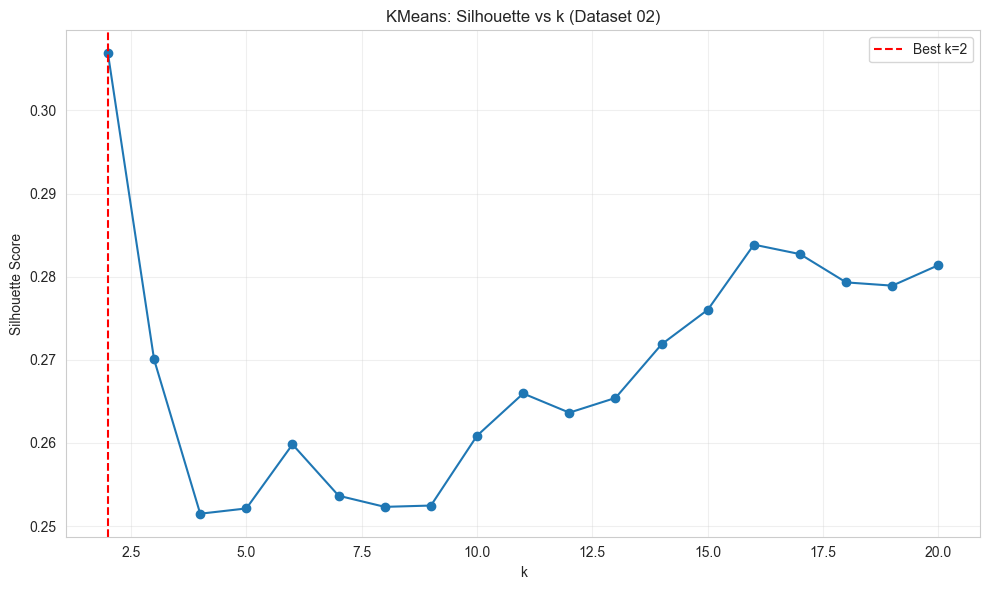

Метрики KMeans (датасет 02):
  silhouette: 0.3069
  davies_bouldin: 1.3235
  calinski_harabasz: 3573.3933


In [18]:
# Подбор k для KMeans (датасет 02)
k_range = range(2, 21)
silhouette_scores_2_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X2_scaled)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X2_scaled, labels)
    else:
        sil = -1
    silhouette_scores_2_kmeans.append(sil)

best_k_2 = k_range[np.argmax(silhouette_scores_2_kmeans)]
print(f"Лучшее k по silhouette: {best_k_2}")

# График silhouette vs k для датасета 02
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores_2_kmeans, marker='o')
plt.axvline(x=best_k_2, color='r', linestyle='--', label=f'Best k={best_k_2}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('KMeans: Silhouette vs k (Dataset 02)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/dataset02_kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Обучение KMeans с лучшим k
kmeans_best_2 = KMeans(n_clusters=best_k_2, random_state=42, n_init=10)
labels_kmeans_2 = kmeans_best_2.fit_predict(X2_scaled)

metrics_kmeans_2 = {
    'silhouette': silhouette_score(X2_scaled, labels_kmeans_2),
    'davies_bouldin': davies_bouldin_score(X2_scaled, labels_kmeans_2),
    'calinski_harabasz': calinski_harabasz_score(X2_scaled, labels_kmeans_2)
}
print("Метрики KMeans (датасет 02):")
for metric, value in metrics_kmeans_2.items():
    print(f"  {metric}: {value:.4f}")


#### DBSCAN


In [19]:
# Подбор параметров для DBSCAN (датасет 02)
eps_range = np.arange(0.1, 2.0, 0.1)
best_eps_2 = None
best_min_samples_2 = 5
best_silhouette_dbscan_2 = -1

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=best_min_samples_2)
    labels = dbscan.fit_predict(X2_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters < 2 or noise_ratio > 0.5:
        continue
        
    mask = labels != -1
    if mask.sum() < 2:
        continue
        
    sil = silhouette_score(X2_scaled[mask], labels[mask])
    if sil > best_silhouette_dbscan_2:
        best_silhouette_dbscan_2 = sil
        best_eps_2 = eps

if best_eps_2 is not None:
    print(f"Лучшие параметры DBSCAN: eps={best_eps_2:.2f}, min_samples={best_min_samples_2}")
    
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2_scaled)
    
    n_clusters_dbscan_2 = len(set(labels_dbscan_2)) - (1 if -1 in labels_dbscan_2 else 0)
    n_noise_dbscan_2 = list(labels_dbscan_2).count(-1)
    noise_ratio_dbscan_2 = n_noise_dbscan_2 / len(labels_dbscan_2)
    
    mask_2 = labels_dbscan_2 != -1
    if mask_2.sum() >= 2:
        metrics_dbscan_2 = {
            'silhouette': silhouette_score(X2_scaled[mask_2], labels_dbscan_2[mask_2]),
            'davies_bouldin': davies_bouldin_score(X2_scaled[mask_2], labels_dbscan_2[mask_2]),
            'calinski_harabasz': calinski_harabasz_score(X2_scaled[mask_2], labels_dbscan_2[mask_2]),
            'noise_ratio': noise_ratio_dbscan_2
        }
        print("\nМетрики DBSCAN (на non-noise точках):")
        for metric, value in metrics_dbscan_2.items():
            print(f"  {metric}: {value:.4f}")
    else:
        metrics_dbscan_2 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': noise_ratio_dbscan_2}
else:
    # Fallback значения
    best_eps_2, best_min_samples_2 = 0.5, 5
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2_scaled)
    metrics_dbscan_2 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': 0.0}


Лучшие параметры DBSCAN: eps=0.60, min_samples=5

Метрики DBSCAN (на non-noise точках):
  silhouette: 0.1382
  davies_bouldin: 0.9020
  calinski_harabasz: 69.3317
  noise_ratio: 0.0226


### 2.3.5. Визуализация (PCA 2D)


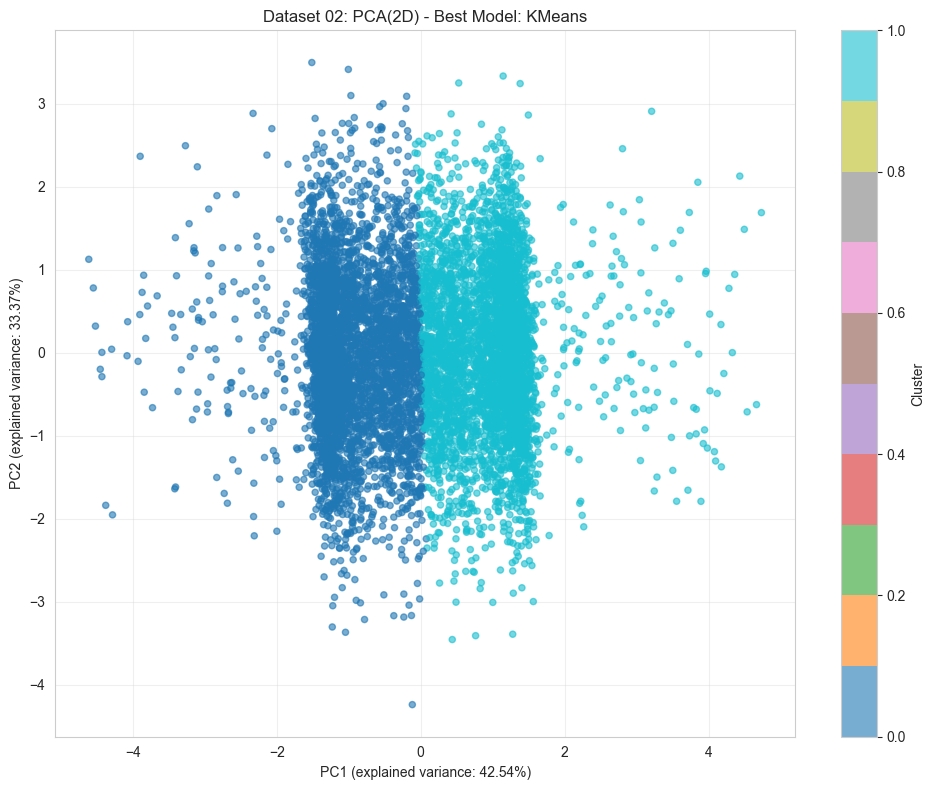

In [20]:
# Определяем лучшую модель для датасета 02
if metrics_kmeans_2['silhouette'] > metrics_dbscan_2.get('silhouette', -1):
    best_labels_2 = labels_kmeans_2
    best_model_name_2 = 'KMeans'
    best_params_2 = {'k': best_k_2}
else:
    best_labels_2 = labels_dbscan_2
    best_model_name_2 = 'DBSCAN'
    best_params_2 = {'eps': best_eps_2, 'min_samples': best_min_samples_2}

# PCA для визуализации (датасет 02)
pca_2 = PCA(n_components=2, random_state=42)
X2_pca = pca_2.fit_transform(X2_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X2_pca[:, 0], X2_pca[:, 1], c=best_labels_2, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 (explained variance: {pca_2.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (explained variance: {pca_2.explained_variance_ratio_[1]:.2%})')
plt.title(f'Dataset 02: PCA(2D) - Best Model: {best_model_name_2}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset02_pca_best.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Датасет 3: S07-hw-dataset-03.csv

### 2.3.1. Загрузка данных и первичный анализ


In [21]:
# Загрузка датасета 03
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print(f"Размер датасета: {df3.shape}")
df3.head()


Размер датасета: (15000, 5)


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [22]:
# Базовая информация и проверка пропусков
print("Информация о данных:")
df3.info()
print(f"\nПропуски: {df3.isnull().sum().sum()}")


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB

Пропуски: 0


In [23]:
# Подготовка признаков (датасет 03)
X3 = df3.drop('sample_id', axis=1)
sample_ids_3 = df3['sample_id']
print(f"Признаки X3: {X3.shape}")


Признаки X3: (15000, 4)


### 2.3.2. Препроцессинг


In [24]:
# Препроцессинг для датасета 03: масштабирование
preprocessor_3 = Pipeline([
    ('scaler', StandardScaler())
])

X3_scaled = preprocessor_3.fit_transform(X3)
print(f"Данные после масштабирования: {X3_scaled.shape}")


Данные после масштабирования: (15000, 4)


### 2.3.3. Модели кластеризации

#### KMeans


Лучшее k по silhouette: 3


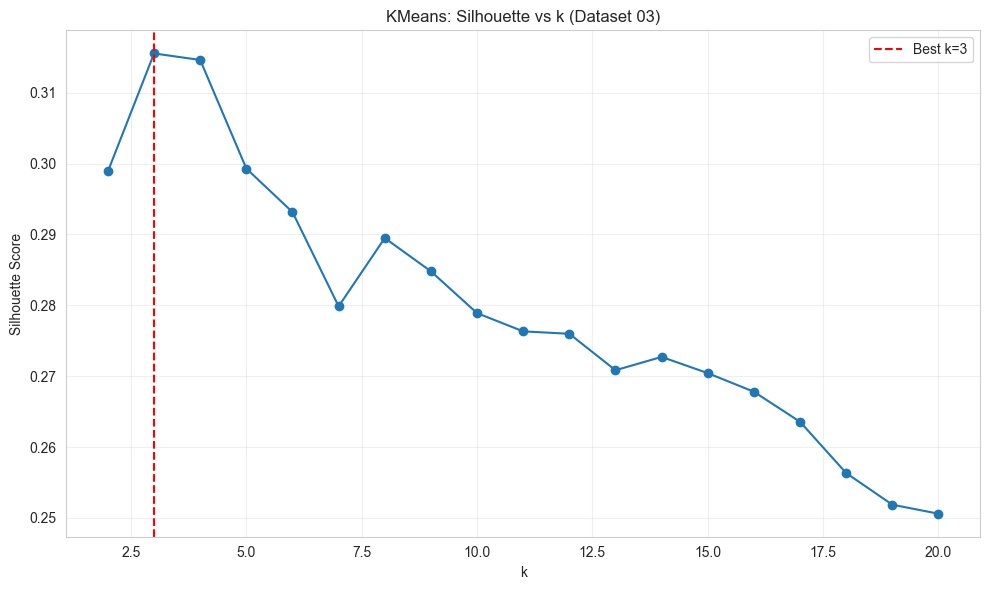

Метрики KMeans (датасет 03):
  silhouette: 0.3155
  davies_bouldin: 1.1577
  calinski_harabasz: 6957.1626


In [25]:
# Подбор k для KMeans (датасет 03)
k_range = range(2, 21)
silhouette_scores_3_kmeans = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X3_scaled)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X3_scaled, labels)
    else:
        sil = -1
    silhouette_scores_3_kmeans.append(sil)

best_k_3 = k_range[np.argmax(silhouette_scores_3_kmeans)]
print(f"Лучшее k по silhouette: {best_k_3}")

# График silhouette vs k для датасета 03
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), silhouette_scores_3_kmeans, marker='o')
plt.axvline(x=best_k_3, color='r', linestyle='--', label=f'Best k={best_k_3}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('KMeans: Silhouette vs k (Dataset 03)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/dataset03_kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Обучение KMeans с лучшим k
kmeans_best_3 = KMeans(n_clusters=best_k_3, random_state=42, n_init=10)
labels_kmeans_3 = kmeans_best_3.fit_predict(X3_scaled)

metrics_kmeans_3 = {
    'silhouette': silhouette_score(X3_scaled, labels_kmeans_3),
    'davies_bouldin': davies_bouldin_score(X3_scaled, labels_kmeans_3),
    'calinski_harabasz': calinski_harabasz_score(X3_scaled, labels_kmeans_3)
}
print("Метрики KMeans (датасет 03):")
for metric, value in metrics_kmeans_3.items():
    print(f"  {metric}: {value:.4f}")


#### DBSCAN


In [26]:
# Подбор параметров для DBSCAN (датасет 03) - кластеры разной плотности + шум
eps_range = np.arange(0.1, 2.0, 0.1)
best_eps_3 = None
best_min_samples_3 = 5
best_silhouette_dbscan_3 = -1

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=best_min_samples_3)
    labels = dbscan.fit_predict(X3_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    if n_clusters < 2 or noise_ratio > 0.5:
        continue
        
    mask = labels != -1
    if mask.sum() < 2:
        continue
        
    sil = silhouette_score(X3_scaled[mask], labels[mask])
    if sil > best_silhouette_dbscan_3:
        best_silhouette_dbscan_3 = sil
        best_eps_3 = eps

if best_eps_3 is not None:
    print(f"Лучшие параметры DBSCAN: eps={best_eps_3:.2f}, min_samples={best_min_samples_3}")
    
    dbscan_best_3 = DBSCAN(eps=best_eps_3, min_samples=best_min_samples_3)
    labels_dbscan_3 = dbscan_best_3.fit_predict(X3_scaled)
    
    n_clusters_dbscan_3 = len(set(labels_dbscan_3)) - (1 if -1 in labels_dbscan_3 else 0)
    n_noise_dbscan_3 = list(labels_dbscan_3).count(-1)
    noise_ratio_dbscan_3 = n_noise_dbscan_3 / len(labels_dbscan_3)
    
    mask_3 = labels_dbscan_3 != -1
    if mask_3.sum() >= 2:
        metrics_dbscan_3 = {
            'silhouette': silhouette_score(X3_scaled[mask_3], labels_dbscan_3[mask_3]),
            'davies_bouldin': davies_bouldin_score(X3_scaled[mask_3], labels_dbscan_3[mask_3]),
            'calinski_harabasz': calinski_harabasz_score(X3_scaled[mask_3], labels_dbscan_3[mask_3]),
            'noise_ratio': noise_ratio_dbscan_3
        }
        print("\nМетрики DBSCAN (на non-noise точках):")
        for metric, value in metrics_dbscan_3.items():
            print(f"  {metric}: {value:.4f}")
    else:
        metrics_dbscan_3 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': noise_ratio_dbscan_3}
else:
    best_eps_3, best_min_samples_3 = 0.5, 5
    dbscan_best_3 = DBSCAN(eps=best_eps_3, min_samples=best_min_samples_3)
    labels_dbscan_3 = dbscan_best_3.fit_predict(X3_scaled)
    metrics_dbscan_3 = {'silhouette': -1, 'davies_bouldin': np.inf, 'calinski_harabasz': 0, 'noise_ratio': 0.0}


Лучшие параметры DBSCAN: eps=0.60, min_samples=5

Метрики DBSCAN (на non-noise точках):
  silhouette: -0.0338
  davies_bouldin: 0.8561
  calinski_harabasz: 16.2962
  noise_ratio: 0.0101


### 2.3.5. Визуализация (PCA 2D)


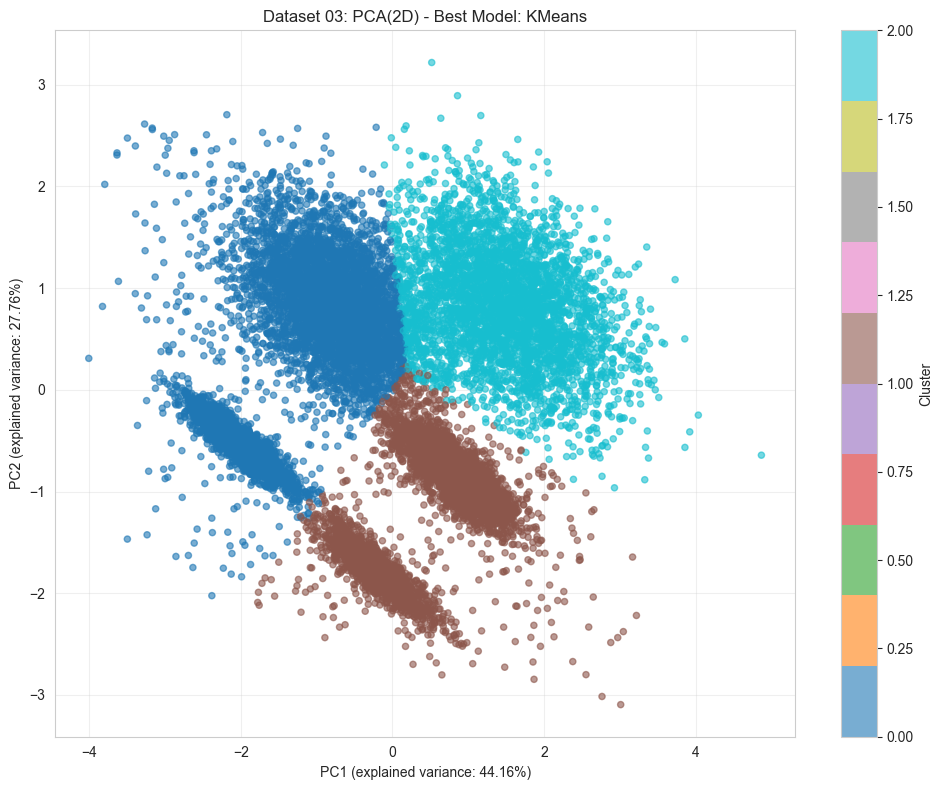

In [27]:
# Определяем лучшую модель для датасета 03
if metrics_kmeans_3['silhouette'] > metrics_dbscan_3.get('silhouette', -1):
    best_labels_3 = labels_kmeans_3
    best_model_name_3 = 'KMeans'
    best_params_3 = {'k': best_k_3}
else:
    best_labels_3 = labels_dbscan_3
    best_model_name_3 = 'DBSCAN'
    best_params_3 = {'eps': best_eps_3, 'min_samples': best_min_samples_3}

# PCA для визуализации (датасет 03)
pca_3 = PCA(n_components=2, random_state=42)
X3_pca = pca_3.fit_transform(X3_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=best_labels_3, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 (explained variance: {pca_3.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 (explained variance: {pca_3.explained_variance_ratio_[1]:.2%})')
plt.title(f'Dataset 03: PCA(2D) - Best Model: {best_model_name_3}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset03_pca_best.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3.6. Устойчивость (для датасета 01)


In [28]:
# Проверка устойчивости KMeans для датасета 01
# 5 запусков с разными random_state
random_states = [42, 123, 456, 789, 999]
labels_list_1 = []

for rs in random_states:
    kmeans = KMeans(n_clusters=best_k_1, random_state=rs, n_init=10)
    labels = kmeans.fit_predict(X1_scaled)
    labels_list_1.append(labels)

# Сравнение разбиений через ARI (с первым разбиением как эталоном)
ari_scores_1 = []
for i in range(1, len(random_states)):
    ari = adjusted_rand_score(labels_list_1[0], labels_list_1[i])
    ari_scores_1.append(ari)

print(f"Устойчивость KMeans (датасет 01) с k={best_k_1}:")
print(f"Средний ARI между разбиениями: {np.mean(ari_scores_1):.4f}")
print(f"Стандартное отклонение ARI: {np.std(ari_scores_1):.4f}")
print(f"\nARI для каждой пары:")
for i, ari in enumerate(ari_scores_1):
    print(f"  Разбиение 0 vs {i+1}: {ari:.4f}")

if np.mean(ari_scores_1) > 0.8:
    print("\nВывод: KMeans показывает высокую устойчивость (>0.8)")
else:
    print("\nВывод: KMeans показывает умеренную устойчивость")


Устойчивость KMeans (датасет 01) с k=2:
Средний ARI между разбиениями: 1.0000
Стандартное отклонение ARI: 0.0000

ARI для каждой пары:
  Разбиение 0 vs 1: 1.0000
  Разбиение 0 vs 2: 1.0000
  Разбиение 0 vs 3: 1.0000
  Разбиение 0 vs 4: 1.0000

Вывод: KMeans показывает высокую устойчивость (>0.8)


### Сохранение артефактов


In [29]:
# Сводка метрик для всех датасетов
metrics_summary = {
    'dataset_01': {
        'KMeans': metrics_kmeans_1,
        'DBSCAN': metrics_dbscan_1
    },
    'dataset_02': {
        'KMeans': metrics_kmeans_2,
        'DBSCAN': metrics_dbscan_2
    },
    'dataset_03': {
        'KMeans': metrics_kmeans_3,
        'DBSCAN': metrics_dbscan_3
    }
}

# Преобразование numpy типов для JSON
def convert_to_serializable(obj):
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_serializable(item) for item in obj]
    elif isinstance(obj, (np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.float64, np.float32)):
        return float(obj)
    return obj

metrics_summary_serializable = convert_to_serializable(metrics_summary)

with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary_serializable, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в artifacts/metrics_summary.json")


Метрики сохранены в artifacts/metrics_summary.json


In [30]:
# Лучшие конфигурации для каждого датасета
best_configs = {
    'dataset_01': {
        'model': best_model_name_1,
        'params': best_params_1,
        'criteria': 'silhouette_score'
    },
    'dataset_02': {
        'model': best_model_name_2,
        'params': best_params_2,
        'criteria': 'silhouette_score'
    },
    'dataset_03': {
        'model': best_model_name_3,
        'params': best_params_3,
        'criteria': 'silhouette_score'
    }
}

best_configs_serializable = convert_to_serializable(best_configs)

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs_serializable, f, indent=2, ensure_ascii=False)

print("Лучшие конфигурации сохранены в artifacts/best_configs.json")


Лучшие конфигурации сохранены в artifacts/best_configs.json


In [31]:
# Сохранение меток лучших моделей для каждого датасета
labels_df_1 = pd.DataFrame({
    'sample_id': sample_ids_1,
    'cluster_label': best_labels_1
})
labels_df_1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

labels_df_2 = pd.DataFrame({
    'sample_id': sample_ids_2,
    'cluster_label': best_labels_2
})
labels_df_2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

labels_df_3 = pd.DataFrame({
    'sample_id': sample_ids_3,
    'cluster_label': best_labels_3
})
labels_df_3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)

print("Метки кластеров сохранены в artifacts/labels/")
print(f"  - labels_hw07_ds1.csv ({best_model_name_1})")
print(f"  - labels_hw07_ds2.csv ({best_model_name_2})")
print(f"  - labels_hw07_ds3.csv ({best_model_name_3})")


Метки кластеров сохранены в artifacts/labels/
  - labels_hw07_ds1.csv (DBSCAN)
  - labels_hw07_ds2.csv (KMeans)
  - labels_hw07_ds3.csv (KMeans)
